# 中介分析 - NBS显著边 → 数字RAN → 阅读流畅性

本notebook进行中介分析，检验NBS显著边（gamma频段）是否通过数字RAN间接影响阅读流畅性。

In [ ]:
# 导入必要的库
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## 1. 配置路径

In [23]:
BASE_PATH = Path('/Users/gaozhenning/Desktop/CodeData/REST_COM-main')

CONN_PATHS = {
    'com': BASE_PATH / 'analysis/connectivity_analysis/com/results',
    'td': BASE_PATH / 'analysis/connectivity_analysis/td/results',
}

NBS_EDGES_PATH = BASE_PATH / 'reports/comparison/nbs/nbs_significant_edges.csv'
BEHAVIOR_PATH = BASE_PATH / '行为数据spss.csv'

OUTPUT_DIR = BASE_PATH / 'reports' / 'comparison' / 'mediation_analysis'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. 加载数据

In [24]:
print("=" * 60)
print("步骤1: 加载数据")
print("=" * 60)

# 加载行为数据
behav_df = pd.read_csv(BEHAVIOR_PATH)
behav_df = behav_df.dropna(subset=['被试编号', '分组'])

subject_to_group = {}
for _, row in behav_df.iterrows():
    subj_id = str(row['被试编号'])[3:]
    subject_to_group[subj_id] = row['分组']

# 加载NBS边
nbs_edges_df = pd.read_csv(NBS_EDGES_PATH)
sig_edges = nbs_edges_df[(nbs_edges_df['pair'] == 'com_vs_td') &
                          (nbs_edges_df['freq_band'] == 'gamma')]

# 加载连接数据
npz_com = np.load(CONN_PATHS['com'] / 'connectivity_results.npz', allow_pickle=True)
npz_td = np.load(CONN_PATHS['td'] / 'connectivity_results.npz', allow_pickle=True)

channel_names = list(npz_com['channel_names'])
ch2idx = {ch: i for i, ch in enumerate(channel_names)}

print(f"COM被试数: {len(npz_com['subject_ids'])}")
print(f"TD被试数: {len(npz_td['subject_ids'])}")
print(f"NBS边数: {len(sig_edges)}")

步骤1: 加载数据
COM被试数: 14
TD被试数: 8
NBS边数: 55


## 3. 提取NBS特征

In [25]:
print("\n" + "=" * 60)
print("步骤2: 提取NBS特征")
print("=" * 60)

# 合并所有数据
all_matrices = np.vstack([npz_com['gamma'], npz_td['gamma']])
all_subj_ids = list(npz_com['subject_ids']) + list(npz_td['subject_ids'])
all_groups = [0] * len(npz_com['subject_ids']) + [1] * len(npz_td['subject_ids'])

# 匹配行为数据
matched_ids = [sid for sid in all_subj_ids if sid in subject_to_group]
matched_indices = [all_subj_ids.index(sid) for sid in matched_ids]
matched_groups = [all_groups[i] for i in matched_indices]

X_list = []
for idx in matched_indices:
    mat = all_matrices[idx]
    features = []
    for _, row in sig_edges.iterrows():
        i = ch2idx.get(row['ch1'])
        j = ch2idx.get(row['ch2'])
        if i is not None and j is not None:
            features.append(float(mat[i, j]))
        else:
            features.append(0.0)
    X_list.append(features)

X_nbs = np.array(X_list, dtype=np.float64)
y_group = np.array(matched_groups)

print(f"NBS特征矩阵: {X_nbs.shape}")
print(f"COM: {np.sum(y_group==0)}, TD: {np.sum(y_group==1)}")


步骤2: 提取NBS特征
NBS特征矩阵: (22, 55)
COM: 14, TD: 8


## 4. 准备行为数据

In [26]:
print("\n" + "=" * 60)
print("步骤3: 准备行为数据")
print("=" * 60)

behav_df['subj_id'] = behav_df['被试编号'].str.replace('BZK', '', regex=False)
behav_filtered = behav_df[behav_df['subj_id'].isin(matched_ids)].copy()
behav_filtered = behav_filtered.set_index('subj_id').loc[matched_ids].reset_index()

mediator_col = '数字RAN均值'
outcome_col = '阅读流畅性'

for col in [mediator_col, outcome_col]:
    behav_filtered[col] = pd.to_numeric(behav_filtered[col], errors='coerce')
    behav_filtered.loc[behav_filtered[col] == -999, col] = np.nan

print(f"有效样本: {len(behav_filtered)}")
print(f"数字RAN非缺失: {behav_filtered[mediator_col].notna().sum()}")
print(f"阅读流畅性非缺失: {behav_filtered[outcome_col].notna().sum()}")


步骤3: 准备行为数据
有效样本: 22
数字RAN非缺失: 22
阅读流畅性非缺失: 22


## 5. NBS特征PCA降维

In [27]:
print("\n" + "=" * 60)
print("步骤4: PCA降维")
print("=" * 60)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_nbs)

pca = PCA(n_components=min(10, X_nbs.shape[1]))
X_pca = pca.fit_transform(X_scaled)

print(f"降维: {X_nbs.shape[1]} → {pca.n_components_}")
print(f"保留方差: {np.sum(pca.explained_variance_ratio_):.2%}")


步骤4: PCA降维
降维: 55 → 10
保留方差: 91.09%


## 6. 中介分析

In [28]:
print("\n" + "=" * 60)
print("步骤5: 中介分析")
print("=" * 60)

# 准备数据
M = behav_filtered[mediator_col].values.astype(float)
Y = behav_filtered[outcome_col].values.astype(float)
X_pca1 = X_pca[:, 0]  # 第一主成分

# 有效数据掩码
valid = ~np.isnan(M) & ~np.isnan(Y)
X_v = X_pca1[valid]
M_v = M[valid]
Y_v = Y[valid]
groups_v = y_group[valid]
n = len(Y_v)

print(f"\n有效样本: {n}")
print(f"  COM: {np.sum(groups_v==0)}, TD: {np.sum(groups_v==1)}")

# 标准化X
X_s = (X_v - X_v.mean()) / X_v.std()


步骤5: 中介分析

有效样本: 22
  COM: 14, TD: 8


In [29]:
# 回归函数
def reg(X, y):
    X = np.asarray(X).flatten().reshape(-1, 1)
    y = np.asarray(y).flatten()
    n = len(y)

    model = LinearRegression()
    model.fit(X, y)
    beta = model.coef_[0]
    y_pred = model.predict(X)
    res = y - y_pred

    ss_res = np.sum(res**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
    df = n - 2
    mse = ss_res / df if df > 0 else 0

    # 标准误: SE = sqrt(MSE / SS_x)
    X_mean = X.mean()
    ss_x = np.sum((X.flatten() - X_mean)**2)
    if ss_x > 0:
        se = np.sqrt(mse / ss_x)
        t = beta / se if se > 0 else 0
        p = 2 * (1 - stats.t.cdf(abs(t), df))
    else:
        se = 0
        p = 1.0

    return beta, se, r2, p

In [30]:
# 路径分析
a, a_se, a_r2, a_p = reg(X_s, M_v)
b, b_se, b_r2, b_p = reg(M_v, Y_v)
c, c_se, c_r2, c_p = reg(X_s, Y_v)

# 直接效应
Xc = np.column_stack([np.ones(n), X_s, M_v])
beta_f = np.linalg.lstsq(Xc, Y_v, rcond=None)[0]
c_prime = beta_f[1]

# 间接效应
indirect = a * b
se_ind = np.sqrt(a**2 * b_se**2 + b**2 * a_se**2)
z_sobel = indirect / se_ind if se_ind > 0 else 0

print(f"\n路径a (NBS边 → 数字RAN): β = {a:.4f}, SE = {a_se:.4f}, p = {a_p:.4f}")
print(f"路径b (数字RAN → 阅读流畅性): β = {b:.4f}, SE = {b_se:.4f}, p = {b_p:.4f}")
print(f"路径c (总效应): β = {c:.4f}, p = {c_p:.4f}")
print(f"路径c' (直接效应): β = {c_prime:.4f}")
print(f"\n间接效应 (a×b) = {indirect:.4f}")
print(f"Sobel SE = {se_ind:.4f}, z = {z_sobel:.3f}")

NameError: name 'stats' is not defined

## 7. Bootstrap检验

In [14]:
# Bootstrap检验
print(f"\nBootstrap检验 (5000次)...")
np.random.seed(42)
boot_ind = np.zeros(5000)
for i in range(5000):
    idx = np.random.choice(n, size=n, replace=True)
    a_b, _, _, _ = reg(X_s[idx], M_v[idx])
    b_b, _, _, _ = reg(M_v[idx], Y_v[idx])
    boot_ind[i] = a_b * b_b

ci_l, ci_u = np.percentile(boot_ind, [2.5, 97.5])
p_boot = min(np.mean(boot_ind <= 0), np.mean(boot_ind >= 0)) * 2
p_boot = min(p_boot, 2.0)
if p_boot > 1:
    p_boot = 2 - p_boot

print(f"Bootstrap 95% CI: [{ci_l:.4f}, {ci_u:.4f}]")
print(f"Bootstrap p-value: {p_boot:.4f}")

if p_boot < 0.05:
    print("结论: ✓ 中介效应显著 (p < 0.05)")
elif p_boot < 0.1:
    print("结论: † 中介效应边缘显著 (p < 0.1)")
else:
    print("结论: ✗ 中介效应不显著 (p >= 0.1)")

if c != 0:
    pm = indirect / c * 100
    print(f"中介比例: {pm:.1f}%")


Bootstrap检验 (5000次)...
Bootstrap 95% CI: [-4.9879, -0.3560]
Bootstrap p-value: 0.0240
结论: ✓ 中介效应显著 (p < 0.05)
中介比例: 55.2%


## 8. 保存结果

In [15]:
print("\n" + "=" * 60)
print("步骤6: 保存结果")
print("=" * 60)

results = {
    'model': 'NBS边 → 数字RAN → 阅读流畅性',
    'comparison': 'com_vs_td',
    'freq_band': 'gamma',
    'n_total': int(n),
    'n_com': int(np.sum(groups_v == 0)),
    'n_td': int(np.sum(groups_v == 1)),
    'path_a': float(a),
    'path_a_se': float(a_se),
    'path_a_p': float(a_p),
    'path_b': float(b),
    'path_b_se': float(b_se),
    'path_b_p': float(b_p),
    'path_c_total': float(c),
    'path_c_prime': float(c_prime),
    'indirect_effect': float(indirect),
    'se_sobel': float(se_ind),
    'z_sobel': float(z_sobel),
    'ci_lower': float(ci_l),
    'ci_upper': float(ci_u),
    'p_bootstrap': float(p_boot),
    'proportion_mediated': float(pm) if c != 0 else np.nan,
    'significant': p_boot < 0.05,
}

pd.DataFrame([results]).to_csv(OUTPUT_DIR / 'mediation_ran_reading.csv', index=False)
print(f"结果已保存: {OUTPUT_DIR / 'mediation_ran_reading.csv'}")


步骤6: 保存结果
结果已保存: /Users/gaozhenning/Desktop/CodeData/REST_COM-main/reports/comparison/mediation_analysis/mediation_ran_reading.csv


## 9. 可视化

图表已保存: /Users/gaozhenning/Desktop/CodeData/REST_COM-main/reports/comparison/mediation_analysis/mediation_ran_reading_plot.png


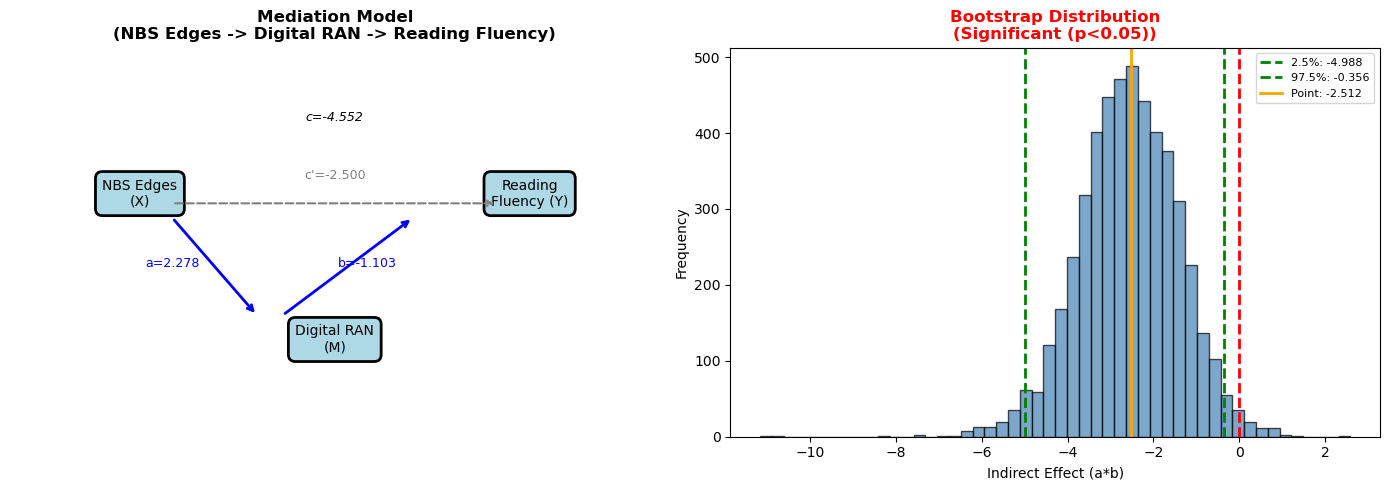

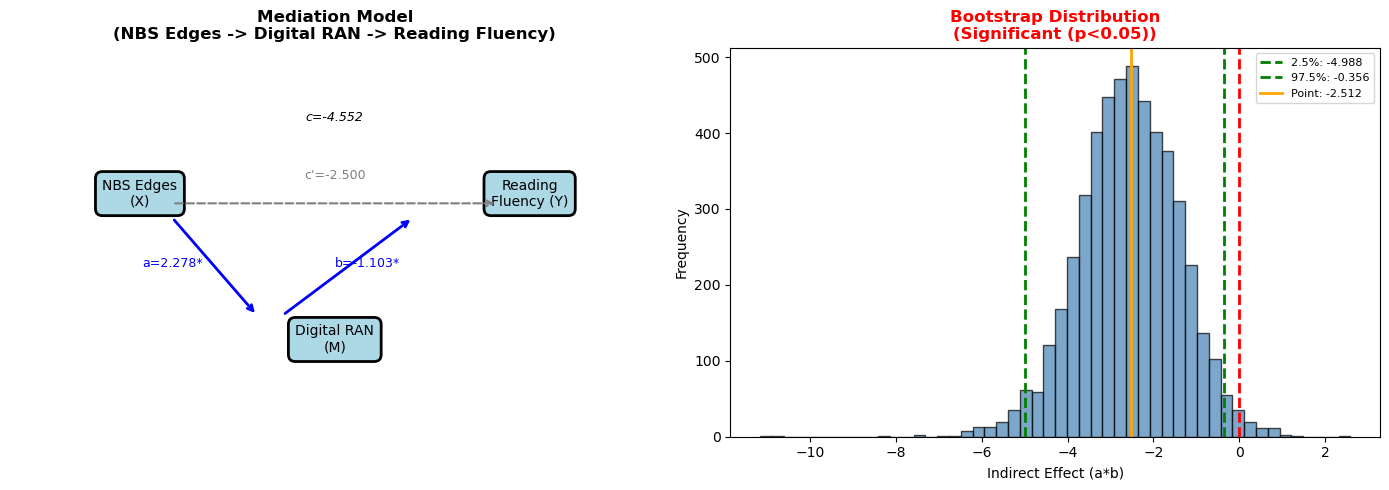

In [37]:
# 可视化
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 图1: 中介模型
ax1 = axes[0]
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 8)
ax1.axis('off')
ax1.set_title('Mediation Model\n(NBS Edges -> Digital RAN -> Reading Fluency)', fontsize=12, fontweight='bold')

node_style = dict(boxstyle='round,pad=0.5', facecolor='lightblue', edgecolor='black', linewidth=2)
ax1.text(2, 5, 'NBS Edges\n(X)', ha='center', va='center', fontsize=10, bbox=node_style)
ax1.text(5, 2, 'Digital RAN\n(M)', ha='center', va='center', fontsize=10, bbox=node_style)
ax1.text(8, 5, 'Reading\nFluency (Y)', ha='center', va='center', fontsize=10, bbox=node_style)

# 路径a标注（带p值）
a_sig = '***' if a_p < 0.001 else '**' if a_p < 0.01 else '*' if a_p < 0.05 else ''
ax1.annotate('', xy=(3.8, 2.5), xytext=(2.5, 4.5), arrowprops=dict(arrowstyle='->', color='blue', lw=2))
ax1.text(2.5, 3.5, f'a={a:.3f}{a_sig}', fontsize=9, color='blue', ha='center')

# 路径b标注（带p值）
b_sig = '***' if b_p < 0.001 else '**' if b_p < 0.01 else '*' if b_p < 0.05 else ''
ax1.annotate('', xy=(6.2, 4.5), xytext=(4.2, 2.5), arrowprops=dict(arrowstyle='->', color='blue', lw=2))
ax1.text(5.5, 3.5, f'b={b:.3f}{b_sig}', fontsize=9, color='blue', ha='center')

ax1.annotate('', xy=(7.5, 4.8), xytext=(2.5, 4.8), arrowprops=dict(arrowstyle='->', color='gray', lw=1.5, linestyle='dashed'))
ax1.text(5, 5.3, f"c'={c_prime:.3f}", fontsize=9, color='gray', ha='center')
ax1.text(5, 6.5, f"c={c:.3f}", fontsize=9, ha='center', style='italic')

# 图2: Bootstrap分布
ax2 = axes[1]
ax2.hist(boot_ind, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax2.axvline(x=ci_l, color='green', linestyle='--', linewidth=2, label=f"2.5%: {ci_l:.3f}")
ax2.axvline(x=ci_u, color='green', linestyle='--', linewidth=2, label=f"97.5%: {ci_u:.3f}")
ax2.axvline(x=indirect, color='orange', linestyle='-', linewidth=2, label=f"Point: {indirect:.3f}")

sig_color = 'red' if p_boot < 0.05 else 'gray'
sig_label = 'Significant (p<0.05)' if p_boot < 0.05 else 'Not Significant'
ax2.set_title(f'Bootstrap Distribution\n({sig_label})', fontsize=12, fontweight='bold', color=sig_color)
ax2.set_xlabel('Indirect Effect (a*b)')
ax2.set_ylabel('Frequency')
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'mediation_ran_reading_plot.png', dpi=150, bbox_inches='tight')
print(f"图表已保存: {OUTPUT_DIR / 'mediation_ran_reading_plot.png'}")
plt.show()

## 完成

分析完成！结果已保存至：
- 数据结果: `mediation_ran_reading.csv`
- 可视化图表: `mediation_ran_reading_plot.png`

**显著性标记说明：**
- `*` p < 0.05
- `**` p < 0.01
- `***` p < 0.001